# GIN Melting Point Prediction

Graph Isomorphism Network (GIN) trained on molecular graphs derived from SMILES strings, with comparison against the XGBoost baseline.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool, global_mean_pool

plt.style.use("ggplot")
torch.manual_seed(97)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
df = pl.read_parquet("../data/processed/baseline_model_features.parquet")
print(df.shape)
df.head()

(3024, 38)


key,name,smiles,mpC,formula,C_count,H_count,O_count,N_count,S_count,F_count,Cl_count,Br_count,I_count,molecular_weight,branch_count,cycle_count,aromatic_ring_count,double_bond_count,triple_bond_count,carboxylic_acid_count,alcohol_count,carbonyl_count,prim_sec_amine_count,amide_count,hbd_count,hba_count,logp,tpsa,rotatable_bond_count,frac_csp3,stereocenters,bertz_ct,bridgehead_atoms,spiro_atoms,heterocycle_count,ring_atom_ratio,split
i64,str,str,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,i32,f64,i32,f64,i32,i32,i32,f64,str
27956,"""cyclobutylmethane""","""C1(CCC1)C""",-161.51,"""C5H10""",5,10,0,0,0,0,0,0,0,70.135,0,1,0,0,0,0,0,0,0,0,0,0,1.8064,0.0,0,1.0,0,27.01955,0,0,0,0.8,"""train"""
16005,"""Nitrogen oxide""","""[O-][N+]#N""",-90.8,"""N2O""",0,0,1,2,0,0,0,0,0,44.013,0,0,0,0,1,0,0,0,0,0,0,2,0.33728,51.21,0,0.0,0,24.264663,0,0,0,0.0,"""train"""
16127,"""Sulfuryl difluoride""","""FS(F)(=O)=O""",-135.8,"""F2O2S""",0,0,2,0,1,2,0,0,0,102.061,1,0,0,2,0,0,0,0,0,0,0,2,0.1702,34.14,0,0.0,0,90.816358,0,0,0,0.0,"""train"""
17138,"""disopyramide""","""CC(C)N(CCC(c1ccccn1)(c2ccccc2)…",94.8,"""C21H29N3O""",21,29,1,3,0,0,0,0,0,339.483,5,2,2,1,0,0,0,1,0,1,1,3,3.3619,59.22,8,0.428571,1,620.555222,0,0,1,0.48,"""train"""
15628,"""Bromine""","""BrBr""",-7.2,"""Br2""",0,0,0,0,0,0,0,2,0,159.808,0,0,0,0,0,0,0,0,0,0,0,0,1.6912,0.0,0,0.0,0,0.0,0,0,0,0.0,"""test"""


In [3]:
checkpoint   = torch.load("../data/processed/graphs.pt", weights_only=False)
graphs       = checkpoint["graphs"]
NODE_DIM     = checkpoint["node_dim"]
EDGE_DIM     = checkpoint["edge_dim"]
MOL_FEAT_DIM = checkpoint["mol_feat_dim"]
print(f"Loaded {len(graphs)} graphs  —  node_dim={NODE_DIM}  edge_dim={EDGE_DIM}  mol_feat_dim={MOL_FEAT_DIM}")

Loaded 3024 graphs  —  node_dim=40  edge_dim=8  mol_feat_dim=16


## Train / Validation / Test Split

Split assignments come from the `split` column in `baseline_model_features.parquet` (assigned in `01_feature_engineering`). Graphs were built in `04_graph_features`.

In [4]:
split_col  = df["split"].to_list()
train_data = [g for g, s in zip(graphs, split_col) if s == "train"]
val_data   = [g for g, s in zip(graphs, split_col) if s == "tune"]
test_data  = [g for g, s in zip(graphs, split_col) if s == "test"]

print(f"Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")

BATCH = 64
train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH)
test_loader  = DataLoader(test_data,  batch_size=BATCH)

Train: 2116  Val: 299  Test: 609


## GIN Model Architecture

Four `GINEConv` layers (GIN with edge features), each followed by BatchNorm + ReLU + Dropout.  
Molecule-level representation: concatenation of global mean pool and global sum pool.  
Regression head: two-layer MLP → scalar prediction.

In [5]:
class GINMelting(nn.Module):
    def __init__(self, node_dim, edge_dim, mol_feat_dim, hidden=128, layers=4, dropout=0.4):
        super().__init__()
        # project input to hidden dim so the first-layer residual has matching shape
        self.input_proj = nn.Linear(node_dim, hidden, bias=False)
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for i in range(layers):
            in_dim = node_dim if i == 0 else hidden
            mlp = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
            )
            self.convs.append(GINEConv(nn=mlp, train_eps=True, edge_dim=edge_dim))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.dropout = nn.Dropout(dropout)
        # readout: mean pool + sum pool + virtual node = hidden*3, then mol descriptors
        self.head = nn.Sequential(
            nn.Linear(hidden * 3 + mol_feat_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr, batch = data.edge_attr, data.batch
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            residual = self.input_proj(x) if i == 0 else x
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
            x = self.dropout(x)
            x = x + residual
        virtual_idx = data.ptr[1:] - 1
        x = torch.cat([
            global_mean_pool(x, batch),
            global_add_pool(x, batch),
            x[virtual_idx],
            data.mol_feat,
        ], dim=1)
        return self.head(x).squeeze(-1)


model = GINMelting(node_dim=NODE_DIM, edge_dim=EDGE_DIM, mol_feat_dim=MOL_FEAT_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(model)

Trainable parameters: 182,253
GINMelting(
  (input_proj): Linear(in_features=40, out_features=128, bias=False)
  (convs): ModuleList(
    (0): GINEConv(nn=Sequential(
      (0): Linear(in_features=40, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    ))
    (1-3): 3 x GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=400, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Training

- Loss: MAE (more robust to the large outliers seen in the baseline errors)
- Optimizer: Adam with weight decay
- LR scheduler: ReduceLROnPlateau (patience 20, factor 0.5)
- Early stopping: patience 40 on validation MAE

In [6]:
def run_epoch(loader, model, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(DEVICE)
            preds = model(batch)
            loss = F.l1_loss(preds, batch.y.squeeze())
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=20, factor=0.5, min_lr=1e-5
)

EPOCHS = 500
PATIENCE = 40
best_val, best_epoch, patience_counter = float("inf"), 0, 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    train_mae = run_epoch(train_loader, model, optimizer)
    val_mae   = run_epoch(val_loader,   model)
    scheduler.step(val_mae)
    train_losses.append(train_mae)
    val_losses.append(val_mae)
    if val_mae < best_val:
        best_val, best_epoch = val_mae, epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    if epoch % 20 == 0 or patience_counter == PATIENCE:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d}  train MAE={train_mae:.2f}  val MAE={val_mae:.2f}  lr={lr:.2e}")
    if patience_counter == PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nBest val MAE: {best_val:.2f} °C  (epoch {best_epoch})")

Epoch  20  train MAE=34.14  val MAE=31.02  lr=1.00e-03
Epoch  40  train MAE=30.74  val MAE=29.86  lr=1.00e-03
Epoch  60  train MAE=27.19  val MAE=28.45  lr=5.00e-04
Epoch  80  train MAE=25.95  val MAE=27.65  lr=5.00e-04
Epoch 100  train MAE=25.52  val MAE=27.10  lr=5.00e-04
Epoch 120  train MAE=25.14  val MAE=27.16  lr=5.00e-04
Epoch 140  train MAE=23.08  val MAE=26.45  lr=2.50e-04
Epoch 160  train MAE=22.45  val MAE=26.05  lr=2.50e-04
Epoch 180  train MAE=22.05  val MAE=26.01  lr=1.25e-04
Epoch 185  train MAE=21.46  val MAE=25.76  lr=1.25e-04
Early stop at epoch 185

Best val MAE: 25.40 °C  (epoch 145)


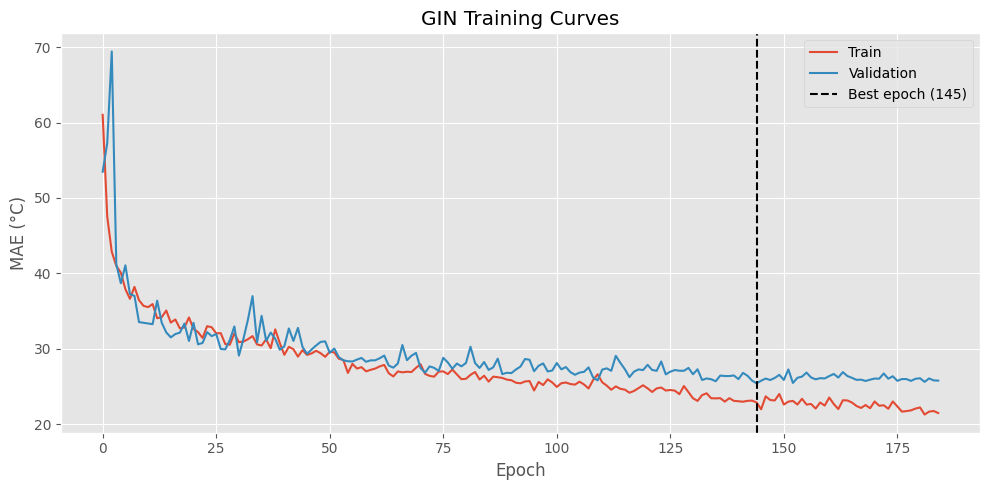

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train")
ax.plot(val_losses,   label="Validation")
ax.axvline(best_epoch - 1, color="k", linestyle="--", label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (°C)")
ax.set_title("GIN Training Curves")
ax.legend()
plt.tight_layout()
plt.show()

## Test Set Evaluation

In [8]:
model.eval()
gnn_preds, gnn_true = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        gnn_preds.append(model(batch).cpu())
        gnn_true.append(batch.y.squeeze().cpu())

gnn_preds = torch.cat(gnn_preds).numpy()
gnn_true  = torch.cat(gnn_true).numpy()

gnn_mae  = mean_absolute_error(gnn_true, gnn_preds)
gnn_rmse = root_mean_squared_error(gnn_true, gnn_preds)
print(f"GIN  — Test MAE:  {gnn_mae:.2f} °C")
print(f"GIN  — Test RMSE: {gnn_rmse:.2f} °C")

GIN  — Test MAE:  26.86 °C
GIN  — Test RMSE: 36.28 °C


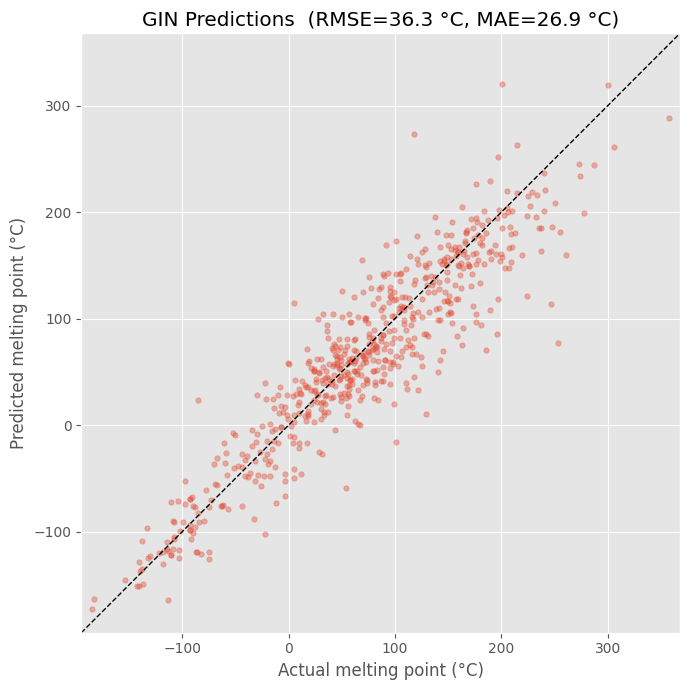

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(gnn_true, gnn_preds, alpha=0.4, s=15)
lims = [min(gnn_true.min(), gnn_preds.min()) - 10,
        max(gnn_true.max(), gnn_preds.max()) + 10]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual melting point (°C)")
ax.set_ylabel("Predicted melting point (°C)")
ax.set_title(f"GIN Predictions  (RMSE={gnn_rmse:.1f} °C, MAE={gnn_mae:.1f} °C)")
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("../data/predictions", exist_ok=True)
(
    pl.DataFrame({
        "key":    df.filter(pl.col("split") == "test")["key"].to_list(),
        "y_true": gnn_true.tolist(),
        "y_pred": gnn_preds.tolist(),
    })
    .write_parquet("../data/predictions/gin_predictions.parquet")
)
print("Saved GIN test predictions.")

Saved GIN test predictions.
